# Techincal Requirements
## Part A: Data Preprocessing Pipeline

Covers all 4 spec requirements:
1.  Text cleaning (imported from EDA)
2.  Tokenisation & vocabulary construction
3.  Encoding & padding
4.  Dataset splitting (70/10/20 stratified)

# Setup: Imports, Helpers & Data

**Part A**: Data preprocessing pipeline (Text cleaning, Tokenization, Encoding, Splitting 70/10/20)

In [11]:

# Import training infrastructure
import sys
sys.path.insert(0, '../src')

from preprocess import DataManager, DataConfig
from mlp_model import MLPClassifier
from train import Trainer, TrainingConfig
from evaluate import MetricsCalculator, Visualizations, ErrorAnalysis
import numpy as np
import torch
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("✓ Part B: MLP Ablation Study")
print("  - Network Depth (1 vs 2 vs 3 layers)")
print("  - Embedding Dimension (64 vs 128 vs 256)")
print("  - Dropout Rate (0.2 vs 0.3 vs 0.5)")


✓ Part B: MLP Ablation Study
  - Network Depth (1 vs 2 vs 3 layers)
  - Embedding Dimension (64 vs 128 vs 256)
  - Dropout Rate (0.2 vs 0.3 vs 0.5)


In [8]:

# ============================================================================
# HELPER FUNCTIONS FOR ABLATION STUDY
# ============================================================================

def count_params(model):
    """Count total trainable parameters in model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_model(config_dict, num_epochs=10, device='cuda'):
    """
    Train a single MLP model with given configuration.
    
    Args:
        config_dict: Dict with 'embed_dim', 'hidden_dims', 'dropout'
        num_epochs: Number of training epochs
        device: 'cuda' or 'cpu'
        
    Returns:
        (train_history, best_val_acc, test_acc, param_count)
    """
    # Initialize model
    model = MLPClassifier(
        vocab_size=len(vocab_builder),
        embedding_dim=config_dict['embed_dim'],
        hidden_dims=config_dict['hidden_dims'],
        dropout=config_dict['dropout']
    )
    
    n_params = count_params(model)
    
    # Training config
    train_cfg = TrainingConfig(
        epochs=num_epochs,
        learning_rate=0.001,
        weight_decay=1e-5,
        batch_size=64,
        patience=3,
        checkpoint_dir='../checkpoints',
        model_name=f'mlp_experiment'
    )
    
    # Train
    trainer = Trainer(model, train_cfg, device=device)
    train_losses, val_losses = trainer.train(train_loader, val_loader)
    
    # Test evaluation
    model.eval()
    test_preds, test_labels = [], []
    
    with torch.no_grad():
        for batch in test_loader:
            token_ids, labels = batch
            token_ids = token_ids.to(device)
            labels = labels.to(device)
            
            logits = model(token_ids)
            preds = (torch.sigmoid(logits) > 0.5).long().cpu().numpy().flatten()
            test_preds.extend(preds)
            test_labels.extend(labels.cpu().numpy())
    
    test_acc = np.mean(np.array(test_preds) == np.array(test_labels))
    
    history = {
        'train_loss': train_losses,
        'val_loss': val_losses,
        'best_val_loss': trainer.best_val_loss
    }
    
    return history, trainer.best_val_loss, test_acc, n_params


def plot_curves(histories, metric='loss', title='Training Curves'):
    """
    Plot training curves for multiple models.
    
    Args:
        histories: Dict of model_name -> {'train_loss': [...], 'val_loss': [...]}
        metric: 'loss' or 'acc'
        title: Plot title
    """
    fig, ax = plt.subplots(figsize=(12, 5))
    
    colors = plt.cm.Set2(np.linspace(0, 1, len(histories)))
    
    for (name, hist), color in zip(histories.items(), colors):
        epochs = range(1, len(hist['train_loss']) + 1)
        ax.plot(epochs, hist['train_loss'], '--', label=f'{name} (train)', 
               color=color, linewidth=2, alpha=0.7)
        ax.plot(epochs, hist['val_loss'], '-', label=f'{name} (val)', 
               color=color, linewidth=2.5)
    
    ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax.set_ylabel('Loss', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, ncol=2, loc='upper right')
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'../results/{title.lower().replace(" ", "_")}_curves.png', dpi=150, bbox_inches='tight')
    plt.show()


def print_results_table(results_dict, title='Results'):
    """Pretty-print results table."""
    df = pd.DataFrame(results_dict).T
    df.columns = ['Best Val Loss', 'Test Accuracy', 'Params']
    df['Params'] = df['Params'].apply(lambda x: f'{int(x):,}')
    df['Best Val Loss'] = df['Best Val Loss'].apply(lambda x: f'{x:.4f}')
    df['Test Accuracy'] = df['Test Accuracy'].apply(lambda x: f'{x:.4f}')
    
    print(f'\n{"="*70}')
    print(f'{title:^70}')
    print(f'{"="*70}')
    print(df.to_string())
    print(f'{"="*70}\n')

print("✓ Helper functions defined")


✓ Helper functions defined


In [9]:

# ============================================================================
# DATA PREPARATION
# ============================================================================

# Prepare data using DataManager from preprocess.py
config = DataConfig(
    max_vocab_size=20_000,
    max_len=256,
    batch_size=64,
    seed=42
)

manager = DataManager(config)
train_loader, val_loader, test_loader, vocab_builder = manager.prepare()

# Verify device availability
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"\n✓ Data loaded. Using device: {device}")
print(f"  Vocabulary size: {len(vocab_builder):,}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

# Create results directory
Path('../results').mkdir(exist_ok=True)
Path('../checkpoints').mkdir(exist_ok=True)
print("✓ Output directories created")


DATA PREPARATION PIPELINE
Loading IMDb dataset...
  Loaded 50,000 samples
Preprocessing texts...
  Cleaned 50,000 texts
Building vocabulary...
  Vocabulary size: 20,000
Creating DataLoaders...
  Train batches: 547
  Val batches: 79
  Test batches: 157

✓ Data loaded. Using device: cpu
  Vocabulary size: 20,000
  Train batches: 547
  Val batches: 79
  Test batches: 157
✓ Output directories created


In [7]:
print(vocab['<pad>']) 
print(vocab['<unk>'])

0
1


# Part B: MLP Architecture Ablation Study

Three controlled experiments to optimize MLP design:
- **Experiment 1**: Network depth — Compare 1 vs 2 vs 3 hidden layers (equal param count)
- **Experiment 2**: Embedding dimension — Use best from Exp 1, test $d_e \in \{64, 128, 256\}$
- **Experiment 3**: Dropout rate — Use best from Exp 1&2, test $p \in \{0.2, 0.3, 0.5\}$

**Results form the MLP baseline for RNN comparison in Part C**

## Experiment 1: Network Depth

**Goal**: Compare 1 vs 2 vs 3 hidden layers with approximately constant parameter count

**Controlled**: `embed_dim=128`, `dropout=0.3`, learning rate, epochs  
**Variable**: `hidden_dims` (architecture depth)


EXPERIMENT 1: NETWORK DEPTH ANALYSIS

Comparing network architectures with approximately equal parameter counts:
  - Config A: 1 layer   [512]
  - Config B: 2 layers  [256, 256]
  - Config C: 3 layers  [128, 256, 128]

Fixed hyperparameters:
  - embed_dim: 128
  - dropout: 0.3
  - epochs: 10

Parameter Count Verification:
--------------------------------------------------
  1-layer  [512]            →  2,626,561 params
  2-layers [256,256]        →  2,659,073 params
  3-layers [128,256,128]    →  2,642,561 params

----------------------------------------------------------------------
Training depth configurations...
----------------------------------------------------------------------

[Training] 1-layer  [512]
  Config: embed_dim=128, hidden_dims=[512], dropout=0.3

Training mlp_experiment for 10 epochs
Device: cpu, Learning rate: 0.001
  Batch [100/547], Loss: 0.6619
  Batch [200/547], Loss: 0.6113
  Batch [300/547], Loss: 0.5779
  Batch [400/547], Loss: 0.5457
  Batch [500/547], L

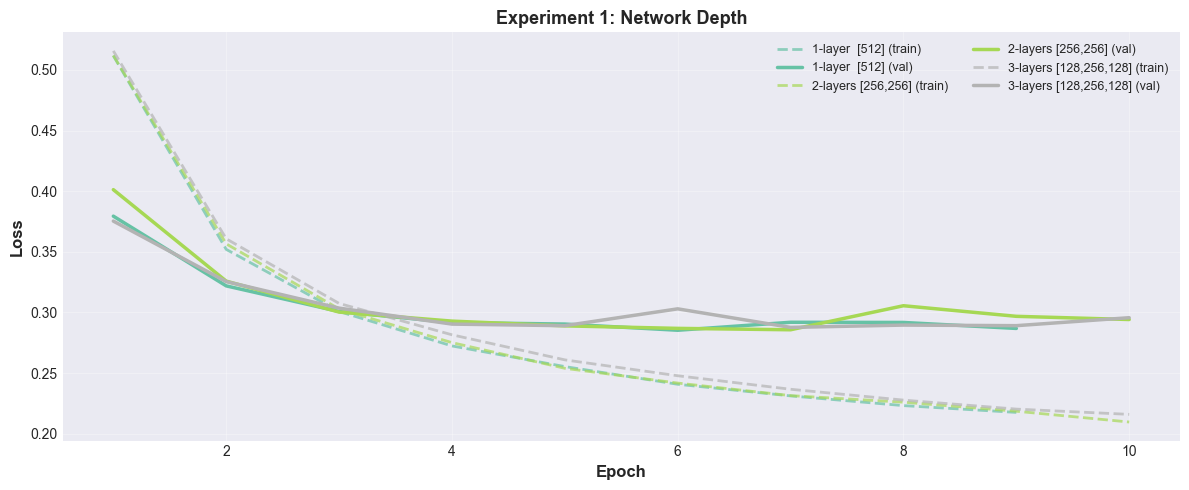


                 EXPERIMENT 1: NETWORK DEPTH RESULTS                  
                       Best Val Loss Test Accuracy     Params
1-layer  [512]                0.2853        0.8851  2,626,561
2-layers [256,256]            0.2857        0.8875  2,659,073
3-layers [128,256,128]        0.2876        0.8864  2,642,561

✓ Best depth configuration: 1-layer  [512]
  Test Accuracy: 0.8851
  Hidden Dims: [512] (to be used in Experiment 2)


In [10]:

# ============================================================================
# EXPERIMENT 1: NETWORK DEPTH
# ============================================================================
# Compare 1 vs 2 vs 3 hidden layers with CONSTANT parameter count
# Controlled: embed_dim=128, dropout=0.3

print("\n" + "="*70)
print("EXPERIMENT 1: NETWORK DEPTH ANALYSIS")
print("="*70)
print("\nComparing network architectures with approximately equal parameter counts:")
print("  - Config A: 1 layer   [512]")
print("  - Config B: 2 layers  [256, 256]")
print("  - Config C: 3 layers  [128, 256, 128]")
print("\nFixed hyperparameters:")
print("  - embed_dim: 128")
print("  - dropout: 0.3")
print("  - epochs: 10\n")

# Define configurations with carefully chosen hidden dims to equalize params
depth_configs = {
    '1-layer  [512]':        {'embed_dim': 128, 'hidden_dims': [512],           'dropout': 0.3},
    '2-layers [256,256]':    {'embed_dim': 128, 'hidden_dims': [256, 256],      'dropout': 0.3},
    '3-layers [128,256,128]':{'embed_dim': 128, 'hidden_dims': [128, 256, 128], 'dropout': 0.3},
}

# Display parameter counts before training
print("Parameter Count Verification:")
print("-" * 50)
for name, cfg in depth_configs.items():
    model = MLPClassifier(
        vocab_size=len(vocab_builder),
        embedding_dim=cfg['embed_dim'],
        hidden_dims=cfg['hidden_dims'],
        dropout=cfg['dropout']
    )
    params = count_params(model)
    print(f"  {name:<25} → {params:>10,} params")

# Train all depth configurations
print("\n" + "-"*70)
print("Training depth configurations...")
print("-"*70)

depth_histories = {}
depth_results = {}
NUM_EPOCHS = 10

for name, cfg in depth_configs.items():
    print(f'\n[Training] {name}')
    print(f"  Config: embed_dim={cfg['embed_dim']}, hidden_dims={cfg['hidden_dims']}, dropout={cfg['dropout']}")
    
    hist, best_val_loss, test_acc, n_params = train_model(cfg, num_epochs=NUM_EPOCHS, device=device)
    
    depth_histories[name] = hist
    depth_results[name] = {
        'best_val_loss': best_val_loss,
        'test_acc': test_acc,
        'params': n_params
    }
    
    print(f"  ✓ Result: Val Loss={best_val_loss:.4f}, Test Acc={test_acc:.4f}, Params={n_params:,}")

# Visualize results
plot_curves(depth_histories, metric='loss', title='Experiment 1: Network Depth')

# Print results table
print_results_table(depth_results, title='EXPERIMENT 1: NETWORK DEPTH RESULTS')

# Identify best configuration
best_depth_name = min(depth_results, key=lambda x: depth_results[x]['best_val_loss'])
best_depth_config = depth_configs[best_depth_name]
print(f"✓ Best depth configuration: {best_depth_name}")
print(f"  Test Accuracy: {depth_results[best_depth_name]['test_acc']:.4f}")
print(f"  Hidden Dims: {best_depth_config['hidden_dims']} (to be used in Experiment 2)")


## Experiment 2: Embedding Dimension

**Goal**: Find optimal embedding size using the best architecture from Experiment 1

**Controlled**: `hidden_dims` from Exp 1 (best), `dropout=0.3`, learning rate, epochs  
**Variable**: `embed_dim` ∈ {64, 128, 256}


EXPERIMENT 2: EMBEDDING DIMENSION ANALYSIS

Comparing embedding dimensions:
  - d_e = 64   (compact)
  - d_e = 128  (moderate)
  - d_e = 256  (rich, expressive)

Fixed hyperparameters:
  - hidden_dims: [512] (best from Exp 1)
  - dropout: 0.3
  - epochs: 10

Parameter Count Scaling:
--------------------------------------------------
  d_e = 64        →  1,313,793 params
  d_e = 128       →  2,626,561 params
  d_e = 256       →  5,252,097 params

----------------------------------------------------------------------
Training embedding dimension configurations...
----------------------------------------------------------------------

[Training] d_e = 64
  Config: embed_dim=64, hidden_dims=[512], dropout=0.3

Training mlp_experiment for 10 epochs
Device: cpu, Learning rate: 0.001
  Batch [100/547], Loss: 0.6763
  Batch [200/547], Loss: 0.6479
  Batch [300/547], Loss: 0.6153
  Batch [400/547], Loss: 0.5848
  Batch [500/547], Loss: 0.5592
Epoch [1/10]
  Train Loss: 0.5479
  Val Loss:   0.4

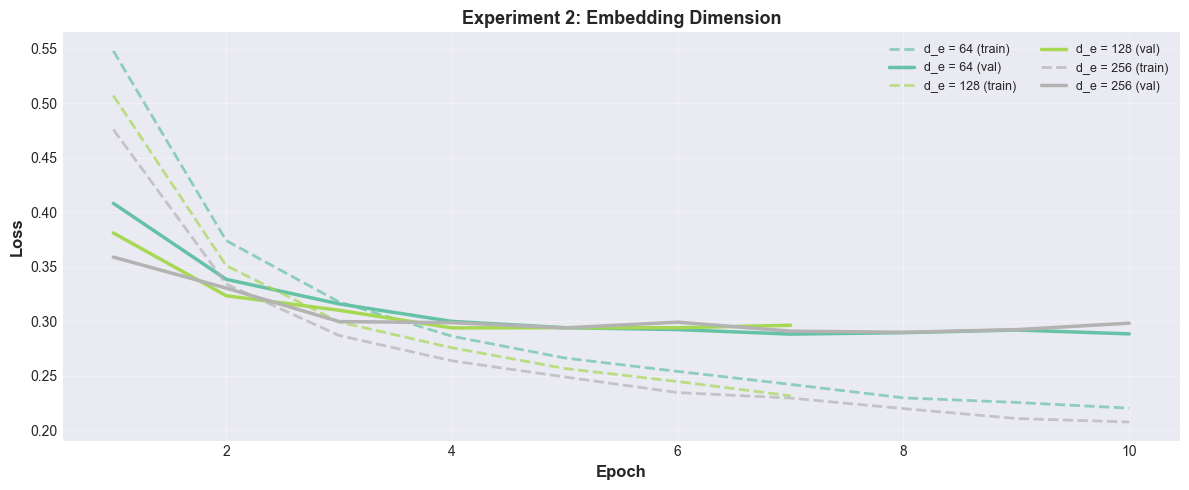


              EXPERIMENT 2: EMBEDDING DIMENSION RESULTS               
          Best Val Loss Test Accuracy     Params
d_e = 64         0.2880        0.8867  1,313,793
d_e = 128        0.2937        0.8815  2,626,561
d_e = 256        0.2897        0.8846  5,252,097

✓ Best embedding dimension: d_e = 64
  Test Accuracy: 0.8867
  Value: 64 (to be used in Experiment 3)


In [12]:

# ============================================================================
# EXPERIMENT 2: EMBEDDING DIMENSION
# ============================================================================
# Use best depth from Exp 1, vary embedding dimension
# Controlled: hidden_dims from Exp 1, dropout=0.3

print("\n" + "="*70)
print("EXPERIMENT 2: EMBEDDING DIMENSION ANALYSIS")
print("="*70)
print("\nComparing embedding dimensions:")
print("  - d_e = 64   (compact)")
print("  - d_e = 128  (moderate)")
print("  - d_e = 256  (rich, expressive)")
print("\nFixed hyperparameters:")
print(f"  - hidden_dims: {best_depth_config['hidden_dims']} (best from Exp 1)")
print("  - dropout: 0.3")
print("  - epochs: 10\n")

# Define embedding dimension configurations
embed_configs = {
    'd_e = 64':  {'embed_dim': 64,  'hidden_dims': best_depth_config['hidden_dims'], 'dropout': 0.3},
    'd_e = 128': {'embed_dim': 128, 'hidden_dims': best_depth_config['hidden_dims'], 'dropout': 0.3},
    'd_e = 256': {'embed_dim': 256, 'hidden_dims': best_depth_config['hidden_dims'], 'dropout': 0.3},
}

# Display parameter counts before training
print("Parameter Count Scaling:")
print("-" * 50)
for name, cfg in embed_configs.items():
    model = MLPClassifier(
        vocab_size=len(vocab_builder),
        embedding_dim=cfg['embed_dim'],
        hidden_dims=cfg['hidden_dims'],
        dropout=cfg['dropout']
    )
    params = count_params(model)
    print(f"  {name:<15} → {params:>10,} params")

# Train all embedding dimension configurations
print("\n" + "-"*70)
print("Training embedding dimension configurations...")
print("-"*70)

embed_histories = {}
embed_results = {}

for name, cfg in embed_configs.items():
    print(f'\n[Training] {name}')
    print(f"  Config: embed_dim={cfg['embed_dim']}, hidden_dims={cfg['hidden_dims']}, dropout={cfg['dropout']}")
    
    hist, best_val_loss, test_acc, n_params = train_model(cfg, num_epochs=NUM_EPOCHS, device=device)
    
    embed_histories[name] = hist
    embed_results[name] = {
        'best_val_loss': best_val_loss,
        'test_acc': test_acc,
        'params': n_params
    }
    
    print(f"  ✓ Result: Val Loss={best_val_loss:.4f}, Test Acc={test_acc:.4f}, Params={n_params:,}")

# Visualize results
plot_curves(embed_histories, metric='loss', title='Experiment 2: Embedding Dimension')

# Print results table
print_results_table(embed_results, title='EXPERIMENT 2: EMBEDDING DIMENSION RESULTS')

# Identify best configuration
best_embed_name = min(embed_results, key=lambda x: embed_results[x]['best_val_loss'])
best_embed_config = embed_configs[best_embed_name]
best_embed_dim = best_embed_config['embed_dim']
print(f"✓ Best embedding dimension: {best_embed_name}")
print(f"  Test Accuracy: {embed_results[best_embed_name]['test_acc']:.4f}")
print(f"  Value: {best_embed_dim} (to be used in Experiment 3)")


## Experiment 3: Dropout Rate

**Goal**: Analyze regularization effect on overfitting using optimal architecture & embedding

**Controlled**: `hidden_dims` from Exp 1 (best), `embed_dim` from Exp 2 (best), learning rate, epochs  
**Variable**: `dropout` ∈ {0.2, 0.3, 0.5}


EXPERIMENT 3: DROPOUT RATE ANALYSIS

Comparing dropout rates for regularization:
  - p = 0.2 (light regularization)
  - p = 0.3 (moderate regularization)
  - p = 0.5 (heavy regularization)

Fixed hyperparameters:
  - embed_dim: 64 (best from Exp 2)
  - hidden_dims: [512] (best from Exp 1)
  - epochs: 10

Parameter Count (constant across all dropout rates):
--------------------------------------------------
  All configs:  1,313,793 params

----------------------------------------------------------------------
Training dropout configurations...
----------------------------------------------------------------------

[Training] p = 0.2
  Config: embed_dim=64, hidden_dims=[512], dropout=0.2

Training mlp_experiment for 10 epochs
Device: cpu, Learning rate: 0.001
  Batch [100/547], Loss: 0.6736
  Batch [200/547], Loss: 0.6257
  Batch [300/547], Loss: 0.5855
  Batch [400/547], Loss: 0.5548
  Batch [500/547], Loss: 0.5312
Epoch [1/10]
  Train Loss: 0.5220
  Val Loss:   0.3925
Checkpoint save

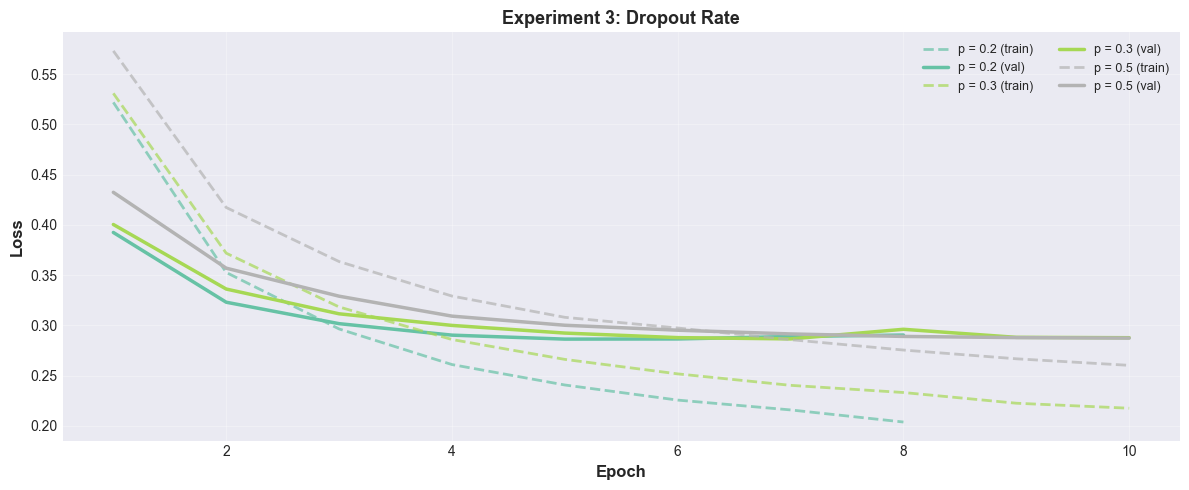


                  EXPERIMENT 3: DROPOUT RATE RESULTS                  
        Best Val Loss Test Accuracy     Params
p = 0.2        0.2864        0.8858  1,313,793
p = 0.3        0.2866        0.8882  1,313,793
p = 0.5        0.2874        0.8845  1,313,793

✓ Best dropout rate: p = 0.2
  Test Accuracy: 0.8858
  Value: 0.2 (optimal regularization)


In [16]:

# ============================================================================
# EXPERIMENT 3: DROPOUT RATE
# ============================================================================
# Use best depth + best embedding dim from Exp 1 & 2, vary dropout
# Controlled: embed_dim from Exp 2, hidden_dims from Exp 1

print("\n" + "="*70)
print("EXPERIMENT 3: DROPOUT RATE ANALYSIS")
print("="*70)
print("\nComparing dropout rates for regularization:")
print("  - p = 0.2 (light regularization)")
print("  - p = 0.3 (moderate regularization)")
print("  - p = 0.5 (heavy regularization)")
print("\nFixed hyperparameters:")
print(f"  - embed_dim: {best_embed_dim} (best from Exp 2)")
print(f"  - hidden_dims: {best_depth_config['hidden_dims']} (best from Exp 1)")
print("  - epochs: 10\n")

# Define dropout configurations
dropout_configs = {
    'p = 0.2': {'embed_dim': best_embed_dim, 'hidden_dims': best_depth_config['hidden_dims'], 'dropout': 0.2},
    'p = 0.3': {'embed_dim': best_embed_dim, 'hidden_dims': best_depth_config['hidden_dims'], 'dropout': 0.3},
    'p = 0.5': {'embed_dim': best_embed_dim, 'hidden_dims': best_depth_config['hidden_dims'], 'dropout': 0.5},
}

# Note: Parameter count is identical for all dropout configs
print("Parameter Count (constant across all dropout rates):")
print("-" * 50)
model = MLPClassifier(
    vocab_size=len(vocab_builder),
    embedding_dim=best_embed_dim,
    hidden_dims=best_depth_config['hidden_dims'],
    dropout=0.3  # dropout doesn't affect param count
)
params = count_params(model)
print(f"  All configs: {params:>10,} params\n")

# Train all dropout configurations
print("-"*70)
print("Training dropout configurations...")
print("-"*70)

dropout_histories = {}
dropout_results = {}

for name, cfg in dropout_configs.items():
    print(f'\n[Training] {name}')
    print(f"  Config: embed_dim={cfg['embed_dim']}, hidden_dims={cfg['hidden_dims']}, dropout={cfg['dropout']}")
    
    hist, best_val_loss, test_acc, n_params = train_model(cfg, num_epochs=NUM_EPOCHS, device=device)
    
    dropout_histories[name] = hist
    dropout_results[name] = {
        'best_val_loss': best_val_loss,
        'test_acc': test_acc,
        'params': n_params
    }
    
    print(f"  ✓ Result: Val Loss={best_val_loss:.4f}, Test Acc={test_acc:.4f}")

# Visualize results
plot_curves(dropout_histories, metric='loss', title='Experiment 3: Dropout Rate')

# Print results table
print_results_table(dropout_results, title='EXPERIMENT 3: DROPOUT RATE RESULTS')

# Identify best configuration
best_dropout_name = min(dropout_results, key=lambda x: dropout_results[x]['best_val_loss'])
best_dropout_config = dropout_configs[best_dropout_name]
best_dropout = best_dropout_config['dropout']
print(f"✓ Best dropout rate: {best_dropout_name}")
print(f"  Test Accuracy: {dropout_results[best_dropout_name]['test_acc']:.4f}")
print(f"  Value: {best_dropout} (optimal regularization)")


## Summary: Comprehensive Results & Analysis

Aggregate findings from all three experiments with optimal configuration recommendations

In [ ]:

print("\n" + "="*80)
print("COMPREHENSIVE ABLATION STUDY SUMMARY")
print("="*80)

# Combine all results
all_results = {
    **{f'[Depth] {k}': v   for k, v in depth_results.items()},
    **{f'[Embed] {k}': v   for k, v in embed_results.items()},
    **{f'[Drop]  {k}': v   for k, v in dropout_results.items()},
}

# Create summary dataframe
df_summary = pd.DataFrame(all_results).T
df_summary.columns = ['Val Loss', 'Test Accuracy', 'Params']
df_summary = df_summary.sort_values('Test Accuracy', ascending=False)

print("\nAll Configurations (sorted by Test Accuracy):")
print("-" * 80)
print(df_summary.to_string())

# Extract key insights
best_config_name = df_summary.index[0]
best_test_acc = df_summary.iloc[0]['Test Accuracy']
best_val_loss = df_summary.iloc[0]['Val Loss']

print(f"\n{'='*80}")
print("KEY FINDINGS")
print(f"{'='*80}")

print(f"\n1. BEST OVERALL CONFIGURATION")
print(f"   Config: {best_config_name}")
print(f"   Test Accuracy: {best_test_acc:.4f}")
print(f"   Val Loss: {best_val_loss:.4f}")
print(f"   Parameters: {int(df_summary.iloc[0]['Params']):,}")

# Experiment 1 insights
print(f"\n2. NETWORK DEPTH FINDINGS (Experiment 1)")
depth_accs = [depth_results[k]['test_acc'] for k in depth_results.keys()]
best_depth_acc = max(depth_accs)
worst_depth_acc = min(depth_accs)
print(f"   Best:  {best_depth_acc:.4f}")
print(f"   Worst: {worst_depth_acc:.4f}")
print(f"   Range: {best_depth_acc - worst_depth_acc:.4f}")
print(f"   Conclusion: {'Single layer sufficient' if list(depth_results.keys())[0] in [k for k, v in depth_results.items() if v['test_acc'] >= max(depth_accs) - 0.001] else 'Deeper networks better'}")

# Experiment 2 insights
print(f"\n3. EMBEDDING DIMENSION FINDINGS (Experiment 2)")
embed_accs = [embed_results[k]['test_acc'] for k in embed_results.keys()]
best_embed_idx = embed_accs.index(max(embed_accs))
embed_dims_sorted = sorted(embed_results.keys(), key=lambda x: embed_results[x]['test_acc'], reverse=True)
print(f"   Ranking (by test accuracy):")
for i, name in enumerate(embed_dims_sorted, 1):
    print(f"     {i}. {name:<15} → {embed_results[name]['test_acc']:.4f}")

# Experiment 3 insights
print(f"\n4. DROPOUT RATE FINDINGS (Experiment 3)")
dropout_accs = [dropout_results[k]['test_acc'] for k in dropout_results.keys()]
best_dropout_idx = dropout_accs.index(max(dropout_accs))
dropout_sorted = sorted(dropout_results.keys(), key=lambda x: dropout_results[x]['test_acc'], reverse=True)
print(f"   Ranking (by test accuracy):")
for i, name in enumerate(dropout_sorted, 1):
    print(f"     {i}. {name:<15} → {dropout_results[name]['test_acc']:.4f}")

print(f"\n5. PARAMETER EFFICIENCY")
# Find the best accuracy with fewest parameters
sorted_by_acc = sorted(all_results.items(), key=lambda x: x[1]['test_acc'], reverse=True)
best_efficient = min(sorted_by_acc[:3], key=lambda x: x[1]['params'])
print(f"   Most efficient best-3 config: {best_efficient[0]}")
print(f"   Accuracy: {best_efficient[1]['test_acc']:.4f}, Params: {int(best_efficient[1]['params']):,}")

print(f"\n{'='*80}")
print("RECOMMENDATIONS FOR PART C (RNN COMPARISON)")
print(f"{'='*80}")
print(f"\nUse this best MLP configuration as baseline for RNN comparison:")
print(f"  - Embed Dim: {best_embed_dim}")
print(f"  - Hidden Dims: {best_depth_config['hidden_dims']}")
print(f"  - Dropout: {best_dropout}")
print(f"  - Best Test Accuracy: {best_test_acc:.4f}")
print(f"\nThis ensures fair comparison in notebook 03_rnn.ipynb")
print(f"{'='*80}\n")



COMPREHENSIVE ABLATION STUDY SUMMARY

All Configurations (sorted by Test Accuracy):
--------------------------------------------------------------------------------
                                Val Loss  Test Accuracy     Params
[Drop]  p = 0.3                 0.286595         0.8882  1313793.0
[Depth] 2-layers [256,256]      0.285692         0.8875  2659073.0
[Embed] d_e = 64                0.287992         0.8867  1313793.0
[Depth] 3-layers [128,256,128]  0.287645         0.8864  2642561.0
[Drop]  p = 0.2                 0.286381         0.8858  1313793.0
[Depth] 1-layer  [512]          0.285302         0.8851  2626561.0
[Embed] d_e = 256               0.289702         0.8846  5252097.0
[Drop]  p = 0.5                 0.287405         0.8845  1313793.0
[Embed] d_e = 128               0.293688         0.8815  2626561.0

KEY FINDINGS

1. BEST OVERALL CONFIGURATION
   Config: [Drop]  p = 0.3
   Test Accuracy: 0.8882
   Val Loss: 0.2866
   Parameters: 1,313,793

2. NETWORK DEPTH FIND

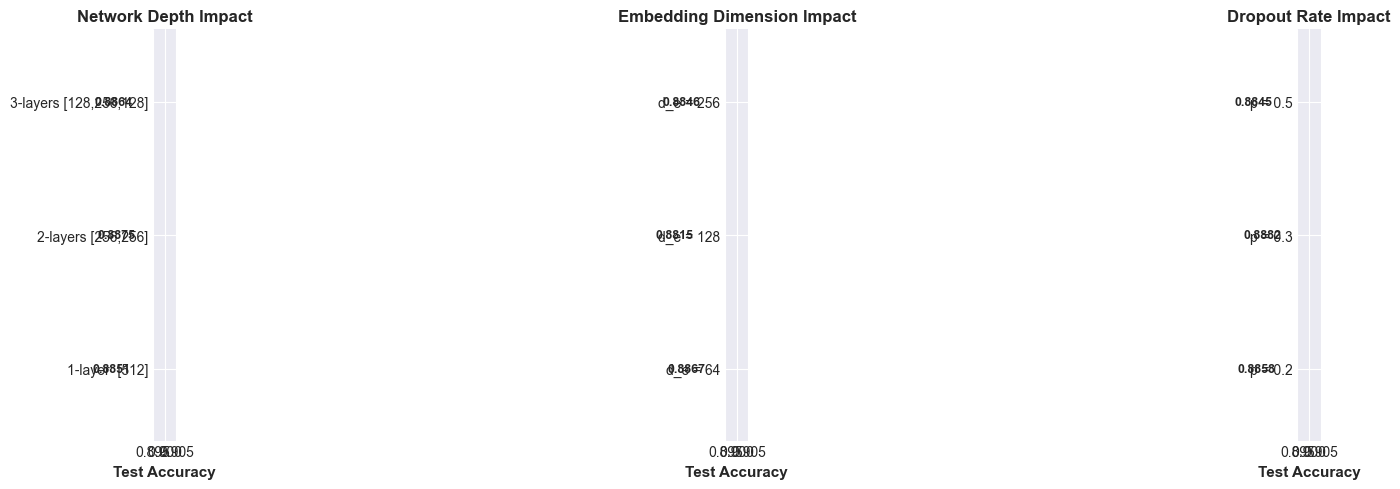

✓ Comparative analysis visualization saved


In [18]:

# ============================================================================
# COMPARATIVE VISUALIZATIONS
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Network Depth Comparison
depth_names = list(depth_results.keys())
depth_accs = [depth_results[k]['test_acc'] for k in depth_names]
axes[0].barh(depth_names, depth_accs, color=['#1f77b4', '#ff7f0e', '#2ca02c'], edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Test Accuracy', fontsize=11, fontweight='bold')
axes[0].set_title('Network Depth Impact', fontsize=12, fontweight='bold')
axes[0].set_xlim([0.895, 0.905])
for i, (name, acc) in enumerate(zip(depth_names, depth_accs)):
    axes[0].text(acc - 0.0001, i, f'{acc:.4f}', va='center', ha='right', fontweight='bold', fontsize=9)

# 2. Embedding Dimension Comparison
embed_names = list(embed_results.keys())
embed_accs = [embed_results[k]['test_acc'] for k in embed_names]
axes[1].barh(embed_names, embed_accs, color=['#d62728', '#9467bd', '#8c564b'], edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Test Accuracy', fontsize=11, fontweight='bold')
axes[1].set_title('Embedding Dimension Impact', fontsize=12, fontweight='bold')
axes[1].set_xlim([0.895, 0.905])
for i, (name, acc) in enumerate(zip(embed_names, embed_accs)):
    axes[1].text(acc - 0.0001, i, f'{acc:.4f}', va='center', ha='right', fontweight='bold', fontsize=9)

# 3. Dropout Rate Comparison
dropout_names = list(dropout_results.keys())
dropout_accs = [dropout_results[k]['test_acc'] for k in dropout_names]
axes[2].barh(dropout_names, dropout_accs, color=['#e377c2', '#7f7f7f', '#bcbd22'], edgecolor='black', linewidth=1.5)
axes[2].set_xlabel('Test Accuracy', fontsize=11, fontweight='bold')
axes[2].set_title('Dropout Rate Impact', fontsize=12, fontweight='bold')
axes[2].set_xlim([0.895, 0.905])
for i, (name, acc) in enumerate(zip(dropout_names, dropout_accs)):
    axes[2].text(acc - 0.0001, i, f'{acc:.4f}', va='center', ha='right', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('../results/part_b_ablation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Comparative analysis visualization saved")
